In [1]:
# | default_exp dmd_dataset

# Building the Dataset for DMD

> We build the dataset for dynamic mode decomposition

#### Imports and Setup

In [2]:
import os
from ast import literal_eval
import torchinfo
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from safetensors.torch import load_model, save_file

from learningdynamics.datasets import YinYangDataset
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.visualization import plot_decision_boundary_movie

In [3]:
# | export
import einops
import torch

In [4]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"

%matplotlib inline

#### Load model trained on binary classification.

We are interested in layer 2 and 3, because they constitute a non-linear layer in the MLP that does not lead to a change in the features' dimensionality. This makes it easier to study, but keeps things non-linear.

In [5]:
file_path = "../saved_weights/model.safetensors"

# Parse metadata
metadata = safetensors_metadata_parser(file_path=file_path)
PROBLEM = metadata["dataset"]

# Load model
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")
model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=3, bias=True)
    (7): ReLU()
    (8): Linear(in_features=3, out_features=2, bias=True)
  )
)

We store the layers we are interested in. We also store the layer just before, or the "prelayer"

In [6]:
PRE_LAYER = [model.features[1]]
LAYERS = [model.features[2], model.features[3]]
# LAYERS = [model.features[2], model.features[3]]

SEED = 250

#### Data control panel

In [7]:
NUM_STATES = 6  # Number of states

In [8]:
NUM_SAMPLES = 30_000
NUM_TRAJECTORIES = NUM_SAMPLES // 2  # Number of trajectories
NUM_LOOP_ITERATIONS = 50  # Length of trajectory

#### Setup the dataset

We are using the yinyang dataset


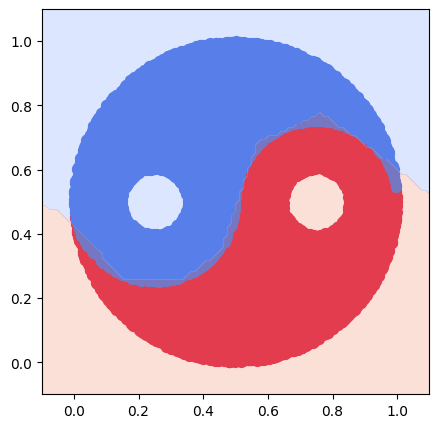

In [9]:
# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=SEED)
else:
    raise NotImplementedError("Unsupported dataset.")
print(f"We are using the {PROBLEM} dataset")

# Plot data
plot_decision_boundary_movie(
    model,
    [model.state_dict()],
    dataset.features,
    dataset.labels.squeeze(),
    figsize=(5, 5),
    labels=[0, 1],
)

In [10]:
## Override

# train_indices = torch.where(dataset.labels == 0)[0]
# test_indices = torch.where(dataset.labels == 1)[0]

# Randomly pick indices for training dataset
train_indices = np.random.choice(
    dataset.features.shape[0], size=NUM_TRAJECTORIES, replace=False
)


# Randomly pick indices for test dataset
test_indices = np.random.choice(
    np.setdiff1d(np.arange(NUM_SAMPLES), train_indices),
    size=int(NUM_SAMPLES - NUM_TRAJECTORIES),
    replace=False,
)

In [11]:
print("Train Indices")
mprint(train_indices)
print()
print("Test Indices")
mprint(test_indices)

Train Indices
<length=15000, 15000 'int64' elements, array>
[1.31e+04, 1.179e+04, 2.113e+04, 4000, ..., 1.885e+04, 7559, 9400, 1.685e+04]

Test Indices
<length=15000, 15000 'int64' elements, array>
[1.988e+04, 2.03e+04, 2.87e+04, 1.516e+04, ..., 2.425e+04, 7415, 2810]


#### Grab activations from the prelayer

In [12]:
# Hook for getting activations
def getActivation(name, activation_dict):
    def hook(model, input, output):
        activation_dict[name] = output.detach()

    return hook

In [13]:
# Dictionary to store activations
activation_dict = {}

# Setup hook name
pre_hook_name = "pre_layer"

# Register the hook
pre_hook = PRE_LAYER[-1].register_forward_hook(
    getActivation(pre_hook_name, activation_dict)
)

# Feed inputs
out = model(dataset.features)

# Remove hook
pre_hook.remove()

pre_hook_act = activation_dict[pre_hook_name]

We want to store the activations from the layer just before the ones we are interested in. This will allow us to loop the layers of interest and get the next state.

In [14]:
print("Pre-layer Activations")
mprint(pre_hook_act[train_indices, :].T)

Pre-layer Activations
<6×15000, 'torch.float32' elements, torch.strided>
┌                                                                            ┐
│   0       0       0        0       0     ...    0       0      0      0    │
│   0       0       0        0       0     ...    0       0      0      0    │
│   0     0.4163  0.1627  0.04144  0.7346  ...  0.8021  1.014  1.26   0.6869 │
│ 0.8109  0.2152    0      1.079   0.5179  ...  0.1924    0      0    0.4904 │
│   0       0       0        0       0     ...    0       0      0      0    │
│ 0.6164  0.7583  0.1279  0.8951   1.382   ...  1.236   1.318  1.301  1.301  │
└                                                                            ┘


#### Layer Looping 

Since we have the output of the "prelayer", we can feed them into the layers of interest to get their activations. We can loop them to get an evolution of the state vector through iterations. 

In [15]:
def iterate_layer(inputs, layers, num_iterations):
    # Initialize the input tensor
    input_tensor = inputs.clone()

    # List to store the outputs at each iteration
    outputs = []

    # Loop for the specified number of iterations
    with torch.no_grad():
        for _ in range(num_iterations):
            # Pass the input through the layers
            for layer in layers:
                input_tensor = layer(input_tensor)

            # Store the output
            outputs.append(input_tensor.detach().clone())

    return outputs

In [16]:
# Put model in eval mode
model.eval()

# Put together loop inputs
train_looping_inputs = pre_hook_act[train_indices, :]

# Loop
raw_train_loop_outputs = iterate_layer(
    inputs=train_looping_inputs,
    layers=LAYERS,
    num_iterations=NUM_LOOP_ITERATIONS - 1,
)

# Stack the outputs
raw_train_loop_outputs = torch.stack(raw_train_loop_outputs)

# Add input
raw_train_states = torch.cat(
    (pre_hook_act[train_indices, :].unsqueeze(0), raw_train_loop_outputs)
)

We verify what all the states for the first trajectory look like

In [17]:
traj_idx = 0
mprint(raw_train_states[:, traj_idx, :].T)

<6×50, 'torch.float32' elements, torch.strided>
┌                                                                              ┐
│   0     1.059   0     0     0     0     ...     0     0     0     0     0    │
│   0     0.6399  0  0.5643   0  0.5643   ...  0.5643   0  0.5643   0  0.5643  │
│   0      2.01   0   1.829   0   1.829   ...   1.829   0   1.829   0   1.829  │
│ 0.8109    0     0     0     0     0     ...     0     0     0     0     0    │
│   0       0     0  0.08594  0  0.08594  ...  0.08594  0  0.08594  0  0.08594 │
│ 0.6164    0     0     0     0     0     ...     0     0     0     0     0    │
└                                                                              ┘


We repeat the same to create a test dataset as well

In [18]:
# Put together loop inputs
test_looping_inputs = pre_hook_act[test_indices, :]

# Loop
raw_test_loop_outputs = iterate_layer(
    inputs=test_looping_inputs,
    layers=LAYERS,
    num_iterations=NUM_LOOP_ITERATIONS - 1,
)

# Stack the outputs
raw_test_loop_outputs = torch.stack(raw_test_loop_outputs)

# Add input
raw_test_states = torch.cat(
    (pre_hook_act[test_indices, :].unsqueeze(0), raw_test_loop_outputs)
)

#### Visualization

We grab one trajectory visualize the heatmap. The matrix should match the matrix we printed above.

In [19]:
print()
print(f"Iterations: {NUM_LOOP_ITERATIONS}")
print(f"Trajectories: {NUM_TRAJECTORIES}")
print(f"States: {NUM_STATES}")
print()

print("Shape:", raw_train_states.shape)


Iterations: 50
Trajectories: 15000
States: 6

Shape: torch.Size([50, 15000, 6])


<6×50, 'torch.float32' elements, torch.strided>
┌                                                                          ┐
│   0     1.388      0        0       0     ...  0     0     0     0     0 │
│   0       0     0.3115   0.05173  0.3607  ...  0  0.5643   0  0.5643   0 │
│ 0.7346  0.6705   1.136   0.5358   1.222   ...  0   1.829   0   1.829   0 │
│ 0.5179    0        0        0       0     ...  0     0     0     0     0 │
│   0       0        0        0       0     ...  0  0.08594  0  0.08594  0 │
│ 1.382     0     0.05769     0       0     ...  0     0     0     0     0 │
└                                                                          ┘


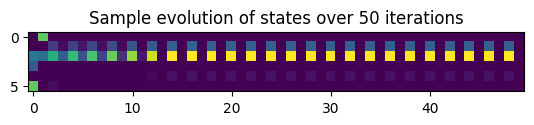

In [20]:
traj_idx = 4
mprint(raw_train_states[:, traj_idx, :].T)
plt.title(f"Sample evolution of states over {NUM_LOOP_ITERATIONS} iterations")
plt.imshow(raw_train_states[:, traj_idx, :].T)
plt.show()

#### Save the tensors

<6×50, 'torch.float32' elements, torch.strided>
┌                                                                          ┐
│   0     0.1028      0      0     0     0  ...  0     0     0     0     0 │
│   0       0       0.564    0  0.5643   0  ...  0  0.5643   0  0.5643   0 │
│ 1.195  0.001335   1.833    0   1.829   0  ...  0   1.829   0   1.829   0 │
│   0       0         0      0     0     0  ...  0     0     0     0     0 │
│   0       0      0.08428   0  0.08594  0  ...  0  0.08594  0  0.08594  0 │
│ 1.052     0      0.007365  0     0     0  ...  0     0     0     0     0 │
└                                                                          ┘


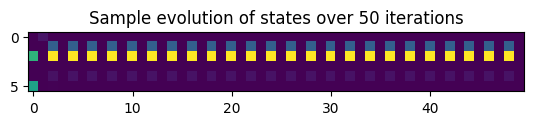

In [21]:
traj_idx = 1
mprint(raw_test_states[:, traj_idx, :].T)
plt.title(f"Sample evolution of states over {NUM_LOOP_ITERATIONS} iterations")
plt.imshow(raw_test_states[:, traj_idx, :].T)
plt.show()

In [22]:
metadata_dict = {
    "NUM_STATES": str(NUM_STATES),
    "NUM_LOOP_ITERATIONS": str(NUM_LOOP_ITERATIONS),
    "NUM_TRAJECTORIES": str(NUM_TRAJECTORIES),
}

save_file(
    {
        "train_states": raw_train_states.contiguous(),
        "test_states": raw_test_states.contiguous(),
        "train_labels": dataset.labels[train_indices],
        "test_labels": dataset.labels[test_indices],
    },
    "../saved_weights/states.safetensors",
    metadata=metadata_dict,
)

#### Reshaping dataset

In [23]:
# | export
def reshape_interleave_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (i t)")

In [24]:
# | export
def reshape_interleave_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (s t) i")

In [25]:
# | export
def reshape_append_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (t i)")

In [26]:
# | export
def reshape_append_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (t s) i")